In [ ]:
import os, glob, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import SimpleITK as sitk

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.ndimage import gaussian_laplace, maximum_filter, binary_fill_holes, label

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


DEVICE: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


In [ ]:
DATA_DIR = r"P:/mlmed2026/labwork4/smallll"  

ANN_CSV = os.path.join(DATA_DIR, "annotations.csv")

SEED = 0
PATCH_SIZE = 48
NEG_PER_POS = 2
BATCH_SIZE = 8
EPOCHS = 8
LR = 1e-3

SIGMAS = [1.5, 2.5, 3.5]    
CAND_THRESHOLD = 0.04      
NMS_SIZE = 5               
MAX_CANDIDATES = 400    

SCORE_THRESH = 0.5          
NMS_DIST_MM = 10.0         

RESAMPLE = True
TARGET_SPACING = (1.0, 1.0, 1.0)  # (x,y,z) mm

OUT_DIR = "pw4_output"
os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


In [ ]:
def discover_scans(data_dir: str):
    paths = glob.glob(os.path.join(data_dir, "**", "*.mhd"), recursive=True)
    return {Path(p).stem: p for p in paths}

scan_paths = discover_scans(DATA_DIR)
print("Found scans:", len(scan_paths))
print("Example IDs:", list(scan_paths.keys())[:5])

annotations = pd.read_csv(ANN_CSV)
annotations = annotations[annotations["seriesuid"].isin(set(scan_paths.keys()))].reset_index(drop=True)

print("Annotations rows:", len(annotations))
print("Annotated scans in your subset:", annotations["seriesuid"].nunique())
annotations.head()


Found scans: 12
Example IDs: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163890911914061745866', '1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760173137525888934217', '1.3.6.1.4.1.14519.5.2.1.6279.6001.106719103982792863757268101375', '1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525711026834210228428', '1.3.6.1.4.1.14519.5.2.1.6279.6001.111017101339429664883879536171']
Annotations rows: 14
Annotated scans in your subset: 8


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760...,-124.834262,127.247155,-473.064479,10.465854
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.106719103982...,-57.087180,74.259266,1790.494057,13.693566
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,42.574154,90.267552,-84.811060,5.916174
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.114218724025...,-127.532989,-29.607902,-253.697616,8.269325
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.114218724025...,93.138882,-5.652615,-213.910616,6.209760


In [ ]:
def load_mhd_sitk(mhd_path: str):
    img = sitk.ReadImage(mhd_path)
    vol_zyx = sitk.GetArrayFromImage(img) 
    return img, vol_zyx

def print_scan_info(uid: str):
    img, vol = load_mhd_sitk(scan_paths[uid])
    print("UID:", uid)
    print("  numpy vol shape (z,y,x):", vol.shape)
    print("  spacing (x,y,z) mm:", img.GetSpacing())
    print("  origin  (x,y,z) mm:", img.GetOrigin())
    print("  HU range:", float(vol.min()), float(vol.max()))
    print("  direction:", img.GetDirection())

uids = sorted(scan_paths.keys())
if len(uids) > 0:
    print_scan_info(uids[0])


UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163890911914061745866
  numpy vol shape (z,y,x): (171, 512, 512)
  spacing (x,y,z) mm: (0.48828125, 0.48828125, 1.7999999523162842)
  origin  (x,y,z) mm: (-127.755859375, -277.755859375, -351.5)
  HU range: -1024.0 1808.0
  direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


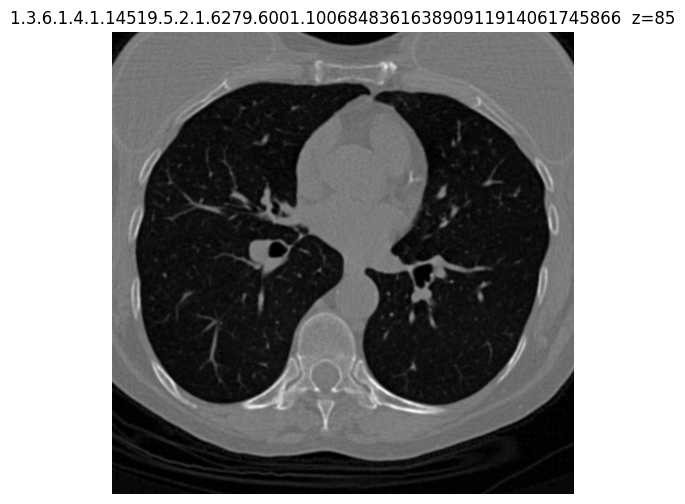

In [ ]:
uid0 = sorted(scan_paths.keys())[0]
img0, vol0 = load_mhd_sitk(scan_paths[uid0])

z = vol0.shape[0] // 2
plt.figure(figsize=(6,6))
plt.imshow(vol0[z], cmap="gray")
plt.title(f"{uid0}  z={z}")
plt.axis("off")
plt.show()


In [ ]:
def resample_sitk(img: sitk.Image, out_spacing=(1.0,1.0,1.0), interp=sitk.sitkLinear):
    in_spacing = img.GetSpacing()
    in_size = img.GetSize()

    out_spacing = tuple(float(s) for s in out_spacing)
    out_size = [
        int(round(in_size[i] * in_spacing[i] / out_spacing[i]))
        for i in range(3)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetInterpolator(interp)
    resampler.SetOutputSpacing(out_spacing)
    resampler.SetSize(out_size)
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(-1000)  # air

    return resampler.Execute(img)

def hu_clip_and_normalize(vol_hu_zyx, hu_min=-1000, hu_max=400):
    v = np.clip(vol_hu_zyx.astype(np.float32), hu_min, hu_max)
    v = (v - hu_min) / float(hu_max - hu_min) 
    return v.astype(np.float32)

def world_to_voxel_zyx(img: sitk.Image, coordX, coordY, coordZ):

    ix, iy, iz = img.TransformPhysicalPointToIndex((float(coordX), float(coordY), float(coordZ)))
    return (int(iz), int(iy), int(ix))

def voxel_zyx_to_world_xyz(img: sitk.Image, voxel_zyx):
    z, y, x = voxel_zyx
    wx, wy, wz = img.TransformIndexToPhysicalPoint((int(x), int(y), int(z)))
    return (float(wx), float(wy), float(wz))


In [ ]:
def coarse_lung_mask(vol_hu_zyx: np.ndarray):
    m = (vol_hu_zyx < -400)
    m = binary_fill_holes(m)
    lbl, n = label(m)
    if n <= 1:
        return m
    sizes = np.bincount(lbl.ravel())
    sizes[0] = 0
    keep = sizes.argsort()[-2:]
    return np.isin(lbl, keep)

def generate_candidates_log_scipy(vol_norm_zyx: np.ndarray,
                                  lung_mask: np.ndarray,
                                  sigmas=(2.0,),
                                  threshold=0.04,
                                  nms_size=5,
                                  max_candidates=400):

    v = vol_norm_zyx * lung_mask.astype(np.float32)
    all_peaks = []

    for sigma in sigmas:
        resp = -gaussian_laplace(v, sigma=sigma)
        mx = maximum_filter(resp, size=nms_size)
        peaks = (resp == mx) & (resp > threshold)
        coords = np.argwhere(peaks)
        if len(coords) == 0:
            continue
        scores = resp[peaks]
        k = min(len(scores), max_candidates)
        idx = np.argsort(scores)[::-1][:k]
        coords = coords[idx]
        scores = scores[idx]
        for (z,y,x), sc in zip(coords, scores):
            all_peaks.append((int(z), int(y), int(x), float(sc), float(sigma)))

    all_peaks.sort(key=lambda t: t[3], reverse=True)
    return all_peaks[:max_candidates]


In [ ]:
def extract_patch(volume_zyx, center_zyx, size=48, pad_value=0.0):
    zc, yc, xc = [int(v) for v in center_zyx]
    r = size // 2

    z0, y0, x0 = zc - r, yc - r, xc - r
    z1, y1, x1 = z0 + size, y0 + size, x0 + size

    patch = np.full((size, size, size), pad_value, dtype=volume_zyx.dtype)

    src_z0, src_z1 = max(z0, 0), min(z1, volume_zyx.shape[0])
    src_y0, src_y1 = max(y0, 0), min(y1, volume_zyx.shape[1])
    src_x0, src_x1 = max(x0, 0), min(x1, volume_zyx.shape[2])

    if (src_z1 <= src_z0) or (src_y1 <= src_y0) or (src_x1 <= src_x0):
        return patch

    dst_z0 = src_z0 - z0
    dst_y0 = src_y0 - y0
    dst_x0 = src_x0 - x0
    dst_z1 = dst_z0 + (src_z1 - src_z0)
    dst_y1 = dst_y0 + (src_y1 - src_y0)
    dst_x1 = dst_x0 + (src_x1 - src_x0)

    patch[dst_z0:dst_z1, dst_y0:dst_y1, dst_x0:dst_x1] = volume_zyx[src_z0:src_z1, src_y0:src_y1, src_x0:src_x1]
    return patch

def dist_mm_zyx(a_zyx, b_zyx, spacing_xyz):
    az, ay, ax = a_zyx
    bz, by, bx = b_zyx
    sx, sy, sz = spacing_xyz  # (x,y,z)
    dz = (az - bz) * sz
    dy = (ay - by) * sy
    dx = (ax - bx) * sx
    return math.sqrt(dx*dx + dy*dy + dz*dz)


In [ ]:
class PatchDataset(Dataset):
    def __init__(self, annotations_df, scan_paths, patch_size=48, neg_per_pos=2, seed=0, augment=True):
        self.ann = annotations_df
        self.scan_paths = scan_paths
        self.patch_size = patch_size
        self.neg_per_pos = neg_per_pos
        self.rng = random.Random(seed)
        self.augment = augment

        self.by_uid = {uid: df for uid, df in self.ann.groupby("seriesuid")}
        self.uids = sorted(self.by_uid.keys())

        self.samples = []
        for uid in self.uids:
            df = self.by_uid[uid]
            for _, r in df.iterrows():
                self.samples.append((uid, (r["coordX"], r["coordY"], r["coordZ"], r["diameter_mm"]), 1))
                for _ in range(self.neg_per_pos):
                    self.samples.append((uid, None, 0))

       
        self.cache = {} 

    def __len__(self):
        return len(self.samples)

    def _load_preprocessed(self, uid: str):
        if uid in self.cache:
            return self.cache[uid]

        img = sitk.ReadImage(self.scan_paths[uid])
        img_rs = resample_sitk(img, TARGET_SPACING, interp=sitk.sitkLinear) if RESAMPLE else img

        vol_hu = sitk.GetArrayFromImage(img_rs).astype(np.float32)  # (z,y,x)
        spacing_xyz = img_rs.GetSpacing()

        self.cache[uid] = (img_rs, vol_hu, spacing_xyz)
        return self.cache[uid]

    def _augment_patch(self, patch):
        if not self.augment:
            return patch

        if self.rng.random() < 0.5: patch = patch[::-1, :, :].copy()
        if self.rng.random() < 0.5: patch = patch[:, ::-1, :].copy()
        if self.rng.random() < 0.5: patch = patch[:, :, ::-1].copy()

        if self.rng.random() < 0.3:
            patch = np.clip(patch + self.rng.uniform(-0.03, 0.03), 0.0, 1.0)
        return patch

    def __getitem__(self, idx):
        uid, info, label = self.samples[idx]
        img_rs, vol_hu, spacing_xyz = self._load_preprocessed(uid)

        if label == 1:
            cx, cy, cz, _diam = info
            center = world_to_voxel_zyx(img_rs, cx, cy, cz)
            j = 3
            center = (center[0] + self.rng.randint(-j,j),
                      center[1] + self.rng.randint(-j,j),
                      center[2] + self.rng.randint(-j,j))
        else:
            lung = coarse_lung_mask(vol_hu)
            coords = np.argwhere(lung)
            if len(coords) == 0:
                center = (self.rng.randrange(vol_hu.shape[0]),
                          self.rng.randrange(vol_hu.shape[1]),
                          self.rng.randrange(vol_hu.shape[2]))
            else:
                pos_rows = self.by_uid[uid]
                pos_centers = [world_to_voxel_zyx(img_rs, r["coordX"], r["coordY"], r["coordZ"])
                               for _, r in pos_rows.iterrows()]

                center = None
                for _ in range(30):
                    z,y,x = coords[self.rng.randrange(len(coords))]
                    c = (int(z),int(y),int(x))
                    if all(dist_mm_zyx(c, pc, spacing_xyz) >= 10.0 for pc in pos_centers):
                        center = c
                        break
                if center is None:
                    z,y,x = coords[self.rng.randrange(len(coords))]
                    center = (int(z),int(y),int(x))


        z,y,x = center
        z = int(np.clip(z, 0, vol_hu.shape[0]-1))
        y = int(np.clip(y, 0, vol_hu.shape[1]-1))
        x = int(np.clip(x, 0, vol_hu.shape[2]-1))
        center = (z,y,x)

        patch_hu = extract_patch(vol_hu, center, size=self.patch_size, pad_value=-1000)
        patch = hu_clip_and_normalize(patch_hu)
        patch = self._augment_patch(patch)

        x = torch.from_numpy(patch[None].astype(np.float32))   # (1,D,H,W)
        y = torch.tensor(float(label), dtype=torch.float32)    
        return x, y


In [ ]:
class Simple3DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 16, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool3d(2),
            nn.Conv3d(16, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool3d(2),
            nn.Conv3d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d(1),
        )
        self.head = nn.Linear(64, 1)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.head(x) 


In [ ]:
def fold_id(uid: str) -> int:
    return abs(hash(uid)) % 10

all_uids = sorted(annotations["seriesuid"].unique().tolist())
FOLD = 0 

train_uids = [u for u in all_uids if fold_id(u) != FOLD]
val_uids   = [u for u in all_uids if fold_id(u) == FOLD]
if len(val_uids) == 0 and len(all_uids) > 1:
    val_uids = [all_uids[-1]]
    train_uids = all_uids[:-1]

print("train scans:", len(train_uids), "val scans:", len(val_uids))

ann_train = annotations[annotations["seriesuid"].isin(train_uids)].reset_index(drop=True)
ann_val   = annotations[annotations["seriesuid"].isin(val_uids)].reset_index(drop=True)

train_ds = PatchDataset(ann_train, scan_paths, patch_size=PATCH_SIZE, neg_per_pos=NEG_PER_POS, seed=SEED, augment=True)
val_ds   = PatchDataset(ann_val,   scan_paths, patch_size=PATCH_SIZE, neg_per_pos=NEG_PER_POS, seed=SEED+999, augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_dl))
print("xb:", xb.shape, xb.dtype, "| yb:", yb.shape, yb.dtype)


train scans: 6 val scans: 2
xb: torch.Size([8, 1, 48, 48, 48]) torch.float32 | yb: torch.Size([8]) torch.float32


In [13]:
model = Simple3DCNN().to(DEVICE)

pos = sum(1 for _,_,lab in train_ds.samples if lab==1)
neg = sum(1 for _,_,lab in train_ds.samples if lab==0)
pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32).to(DEVICE)
print("pos:", pos, "neg:", neg, "pos_weight:", float(pos_weight.item()))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = 1e9
best_state = None
history = {"train": [], "val": []}

for ep in range(1, EPOCHS+1):
    model.train()
    tr_loss, ntr = 0.0, 0
    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)             # (B,)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb).squeeze(1)  # (B,)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        tr_loss += float(loss.item()) * xb.size(0)
        ntr += xb.size(0)
    tr_loss /= max(ntr, 1)

    model.eval()
    va_loss, nva = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            va_loss += float(loss.item()) * xb.size(0)
            nva += xb.size(0)
    va_loss /= max(nva, 1)

    history["train"].append(tr_loss)
    history["val"].append(va_loss)

    print(f"Epoch {ep:02d}/{EPOCHS} | train={tr_loss:.4f} | val={va_loss:.4f}")

    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

print("Best val loss:", best_val)

CKPT_PATH = os.path.join(OUT_DIR, "simple3dcnn_best.pt")
torch.save(best_state, CKPT_PATH)
print("Saved:", CKPT_PATH)


pos: 10 neg: 20 pos_weight: 2.0
Epoch 01/8 | train=0.9325 | val=0.9224
Epoch 02/8 | train=0.9207 | val=0.9167
Epoch 03/8 | train=0.9144 | val=0.8859
Epoch 04/8 | train=0.8884 | val=0.8512
Epoch 05/8 | train=0.8527 | val=0.7533
Epoch 06/8 | train=0.7769 | val=0.8260
Epoch 07/8 | train=0.7340 | val=0.7974
Epoch 08/8 | train=0.5800 | val=0.4944
Best val loss: 0.4943852424621582
Saved: pw4_output\simple3dcnn_best.pt


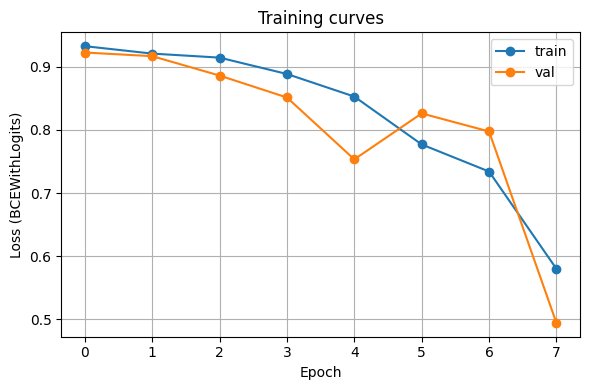

In [14]:
plt.figure(figsize=(6,4))
plt.plot(history["train"], marker="o", label="train")
plt.plot(history["val"], marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCEWithLogits)")
plt.title("Training curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import torch

def compute_binary_metrics(y_true, y_prob, thr=0.5):

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    eps = 1e-9
    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    f1   = 2 * prec * rec / (prec + rec + eps)
    spec = tn / (tn + fp + eps)

    return {
        "threshold": thr,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "specificity": spec,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn
    }

In [ ]:
def eval_classifier(model, dl, thr=0.5, device="cpu"):
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb).squeeze(1)   
            prob = torch.sigmoid(logits)         
            y_true.extend(yb.detach().cpu().numpy().tolist())
            y_prob.extend(prob.detach().cpu().numpy().tolist())

    metrics = compute_binary_metrics(y_true, y_prob, thr=thr)
    return metrics, (y_true, y_prob)

metrics, _ = eval_classifier(model, val_dl, thr=0.5, device=DEVICE)
metrics

{'threshold': 0.5,
 'accuracy': 0.75,
 'precision': 0.5714285713469388,
 'recall': 0.99999999975,
 'f1': 0.7272727266776859,
 'specificity': 0.624999999921875,
 'tp': 4,
 'tn': 5,
 'fp': 3,
 'fn': 0}

In [23]:
def print_metrics(m):
    print(f"Threshold:   {m['threshold']}")
    print(f"Accuracy:    {m['accuracy']:.4f}")
    print(f"Precision:   {m['precision']:.4f}")
    print(f"Recall:      {m['recall']:.4f}")
    print(f"F1-score:    {m['f1']:.4f}")
    print(f"Specificity: {m['specificity']:.4f}")
    print(f"TP/TN/FP/FN: {m['tp']}/{m['tn']}/{m['fp']}/{m['fn']}")

for thr in [0.3, 0.5, 0.7]:
    m, _ = eval_classifier(model, val_dl, thr=thr, device=DEVICE)
    print("="*35)
    print_metrics(m)

Threshold:   0.3
Accuracy:    0.6667
Precision:   0.5000
Recall:      1.0000
F1-score:    0.6667
Specificity: 0.5000
TP/TN/FP/FN: 4/4/4/0
Threshold:   0.5
Accuracy:    0.8333
Precision:   0.6667
Recall:      1.0000
F1-score:    0.8000
Specificity: 0.7500
TP/TN/FP/FN: 4/6/2/0
Threshold:   0.7
Accuracy:    0.8333
Precision:   0.7500
Recall:      0.7500
F1-score:    0.7500
Specificity: 0.8750
TP/TN/FP/FN: 3/7/1/1


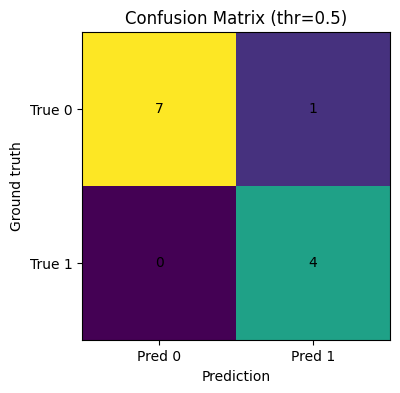

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_from_probs(y_true, y_prob, thr=0.5):
    y_true = np.array(y_true).astype(int)
    y_pred = (np.array(y_prob) >= thr).astype(int)

    tp = ((y_pred==1) & (y_true==1)).sum()
    tn = ((y_pred==0) & (y_true==0)).sum()
    fp = ((y_pred==1) & (y_true==0)).sum()
    fn = ((y_pred==0) & (y_true==1)).sum()

    cm = np.array([[tn, fp],
                   [fn, tp]])

    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (thr={thr})")
    plt.xticks([0,1], ["Pred 0", "Pred 1"])
    plt.yticks([0,1], ["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i,j]), ha="center", va="center")
    plt.xlabel("Prediction")
    plt.ylabel("Ground truth")
    plt.show()

m, (yt, yp) = eval_classifier(model, val_dl, thr=0.5, device=DEVICE)
plot_confusion_from_probs(yt, yp, thr=0.5)

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import SimpleITK as sitk

def luna_subset_stats(data_dir, ann_csv):
    mhd_paths = sorted(glob.glob(os.path.join(data_dir, "**", "*.mhd"), recursive=True))
    uids = [os.path.splitext(os.path.basename(p))[0] for p in mhd_paths]
    n_scans = len(uids)

    ann = pd.read_csv(ann_csv)
    ann_sub = ann[ann["seriesuid"].isin(set(uids))]
    n_nodules = len(ann_sub)

    spacings = []
    for p in mhd_paths:
        img = sitk.ReadImage(p)
        spacings.append(img.GetSpacing()) 

    spacings = np.array(spacings, dtype=float) if len(spacings) else np.zeros((0,3), dtype=float)
    overall_min = float(spacings.min()) if len(spacings) else float("nan")
    overall_max = float(spacings.max()) if len(spacings) else float("nan")

    return n_scans, n_nodules, overall_min, overall_max

N_SCANS, N_NODULES, SP_MIN, SP_MAX = luna_subset_stats(DATA_DIR, ANN_CSV)
print("N_SCANS   =", N_SCANS)
print("N_NODULES =", N_NODULES)
print("Spacing range (mm) BEFORE resampling =", f"{SP_MIN:.3f}--{SP_MAX:.3f}")


N_SCANS   = 12
N_NODULES = 14
Spacing range (mm) BEFORE resampling = 0.488--2.500
